### Лабораторная работа №5

#### Импорты / настройки

In [1]:
import time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import models
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from collections import Counter
from pathlib import Path
import plotly.graph_objects as go
import matplotlib.pyplot as plt #noqa

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

#### Подготовка данных

In [3]:
train_dataset_search_param = CIFAR10(root='./data', train=True, download=True, transform=transforms.ToTensor())

c:\projects\pstu-machine-learning-models-and-technologies\lab_work_5\src\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [4]:
# Размер для масштабирования картинок
RESCALE_SIZE_CIFAR10 = [train_dataset_search_param.data.shape[1], train_dataset_search_param.data.shape[2]]
# Размер батча
BATCH_SIZE = 64

In [5]:
train_loader_search_param = DataLoader(train_dataset_search_param, batch_size=BATCH_SIZE, shuffle=False)

Расчитаем mean и std для CIFAR10 ([stackoverflow](https://stackoverflow.com/questions/60101240/finding-mean-and-standard-deviation-across-image-channels-pytorch))

In [6]:
nimages = 0
mean = torch.zeros(3)
std = torch.zeros(3)
for batch, _ in tqdm(train_loader_search_param, desc='Расчет mean и std CIFAR10'):
    # batch: [batch, channels, height, width] -> [64, 3, 32, 32]
    batch = batch.view(batch.size(0), batch.size(1), -1) # [64, 3, 32 * 32]
    # Cчитаем количество изображений в батче
    nimages += batch.size(0)
    # Cчитаем среднее для каждого канала, считаем сумму по всем каналам
    mean += batch.mean(2).sum(0)
    # Cчитаем стандартное отклоенение для каждого канала, считаем сумму по всем каналам
    std += batch.std(2).sum(0)

Расчет mean и std CIFAR10:   0%|          | 0/782 [00:00<?, ?it/s]

In [7]:
NORMALIZE_MEAN_CIFAR10 = mean / nimages
NORMALIZE_STD_CIFAR10 = std / nimages

In [8]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(NORMALIZE_MEAN_CIFAR10, NORMALIZE_STD_CIFAR10)
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(NORMALIZE_MEAN_CIFAR10, NORMALIZE_STD_CIFAR10)
])

Посмотрим на дисбаланс классов

In [9]:
target_counter = Counter(train_dataset_search_param.targets)
target_counter

Counter({6: 5000,
         9: 5000,
         4: 5000,
         1: 5000,
         2: 5000,
         7: 5000,
         8: 5000,
         3: 5000,
         5: 5000,
         0: 5000})

In [10]:
train_dataset = CIFAR10(root='./data', train=True, download=False, transform=transform_train)
test_dataset = CIFAR10(root='./data', train=False, download=True, transform=transform_test)

In [11]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

In [12]:
loaders = {
    'train': train_loader,
    'val': test_loader
}

In [13]:
def show_images(dataset, n_rows=2, n_cols=2, normalized=True) -> None:
    fig, ax = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4))
    # Цикл повторяется (n_rows * n_cols) раз
    for fig_x in ax.flatten():
        idx = int(np.random.uniform(0, len(dataset)))
        img_tensor, img_target = dataset[idx]
        img_numpy = img_tensor.numpy().transpose(1, 2, 0) # [C, H, W] -> [H, W, C]
        if not normalized:
            # Обратная нормализация (оригинал по цвету)
            img_numpy = NORMALIZE_STD_CIFAR10 * img_numpy + NORMALIZE_MEAN_CIFAR10
        img_class = dataset.classes[img_target]
        fig_x.imshow(img_numpy)
        fig_x.set_title(f'{img_class} ({img_target})')
    fig.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290555..2.4223638].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290555..1.5442326].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290555..2.617504].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4218991..2.3589995].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290555..2.4028497].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290555..2.754102].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290555.

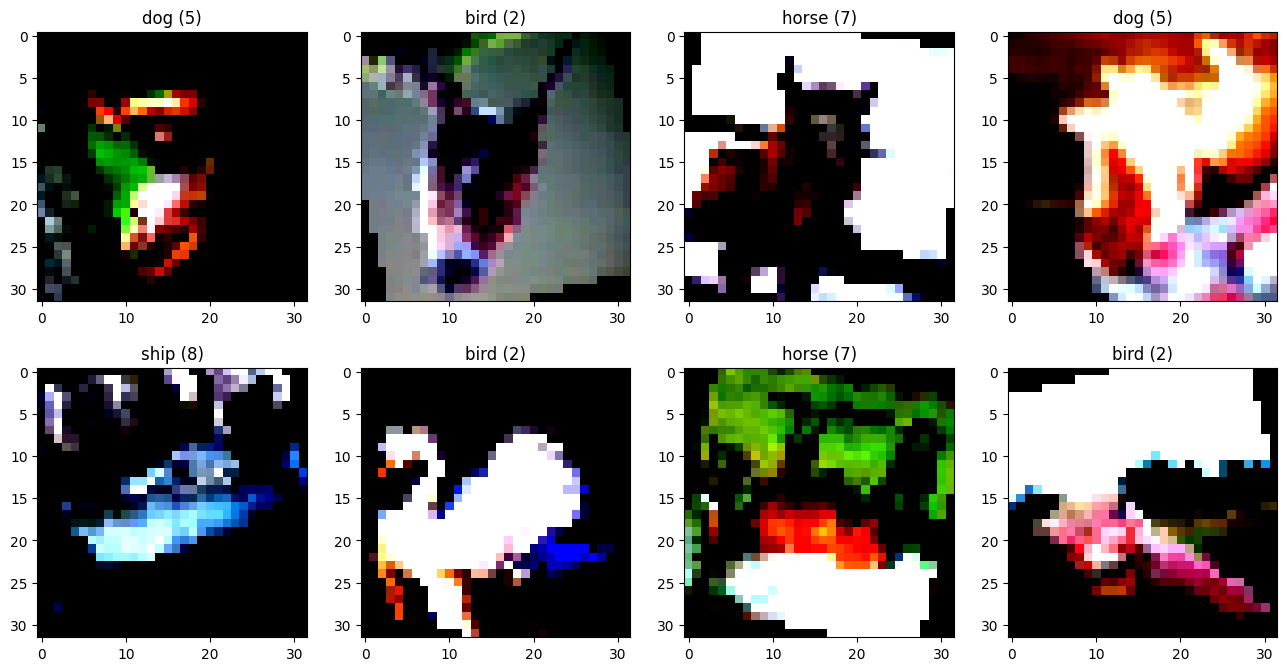

In [14]:
show_images(train_dataset, 2, 4, True)

#### Определение функций

- [Чекпоинтинг](https://docs.pytorch.org/tutorials/beginner/saving_loading_models.html)
- Обучение одной эпохи
- Валидация одной эпохи
- Обучение и валидация на N эпох

In [15]:
def checkpoint(dir, i_epoch, model, optimizer, **kwargs):
    save_dict = {key: value for key, value in kwargs.items()}
    save_dict['epoch'] = i_epoch + 1
    save_dict['model_state_dict'] = model.state_dict()
    save_dict['optimizer_state_dict'] = optimizer.state_dict()
    folder_path = Path(dir)
    folder_path.mkdir(exist_ok=True)
    checkpoint_path = folder_path / f'epoch_{i_epoch + 1}.pt'
    torch.save(save_dict, checkpoint_path)
    return

In [16]:
def fit_one_epoch(model, train_loader, optimizer, criterion):
    model.train()
    losses_epoch = []
    y_true_epoch = []
    y_pred_epoch = []
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        preds = logits.argmax(-1)
        losses_epoch.append(loss.item())
        y_true_epoch.extend(y_batch.cpu().tolist())
        y_pred_epoch.extend(preds.cpu().tolist())
    losses_mean = sum(losses_epoch) / len(losses_epoch)
    accuracy = accuracy_score(y_true_epoch, y_pred_epoch)
    return losses_mean, accuracy

In [17]:
def eval_one_epoch(model, val_loader, criterion):
    model.eval()
    losses_epoch = []
    y_true_epoch = []
    y_pred_epoch = []
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        with torch.no_grad():
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
        preds = logits.argmax(-1)
        losses_epoch.append(loss.item())
        y_true_epoch.extend(y_batch.cpu().tolist())
        y_pred_epoch.extend(preds.cpu().tolist())
    losses_mean = sum(losses_epoch) / len(losses_epoch)
    accuracy = accuracy_score(y_true_epoch, y_pred_epoch)
    return losses_mean, accuracy

In [18]:
def train_model(model, loaders, optimizer, criterion, epoch, dir=None, i_epoch_start=0):
    if not dir:
        dir = f'{model._get_name()}_{time.time()}'
    pbar = tqdm(range(i_epoch_start, epoch + i_epoch_start))
    for i_epoch in pbar:
        pbar.set_description(f'(train) Epoch {i_epoch + 1}')
        train_loss, train_acc = fit_one_epoch(model, loaders['train'], optimizer, criterion)
        pbar.write(f'\t(train) Epoch {i_epoch + 1}: loss ({train_loss}) | acc ({train_acc})')
        pbar.set_description(f'(eval) Epoch {i_epoch + 1}')
        val_loss, val_acc = eval_one_epoch(model, loaders['val'], criterion)
        pbar.write(f'\t(eval) Epoch {i_epoch + 1}: loss ({val_loss}) | acc ({val_acc})')
        pbar.set_description('Checkpointing')
        checkpoint(dir, i_epoch, model, optimizer, 
                   train_loss=train_loss, train_acc=train_acc,
                   val_loss=val_loss, val_acc=val_acc)
    return

In [19]:
def predict(model, loader):
    model.eval()
    all_preds = []
    all_true = []
    pbar = tqdm(loader, desc='Test mode')
    for X_batch, y_batch in pbar:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        with torch.no_grad():
            logits = model(X_batch)
        preds = logits.argmax(-1)
        all_preds.extend(preds.cpu().tolist())
        all_true.extend(y_batch.cpu().tolist())
    return all_preds

#### SimpleCNN

In [20]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=4096, out_features=512),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(in_features=512, out_features=10)
        )
    def forward(self, x):
        x = self.features(x)
        logits = self.classifier(x)
        return logits

In [74]:
simple_cnn = SimpleCNN()
simple_cnn.to(device)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)

In [75]:
optimizer = torch.optim.AdamW(simple_cnn.parameters(), lr=1e-4, weight_decay=1e-3)
criterion = nn.CrossEntropyLoss()
# train_model(simple_cnn, loaders, optimizer, criterion, 100, 'SimpleCNN') # 40:05

#### Подготовка данных для ResNet-18

In [21]:
transform_train_resnet18 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(NORMALIZE_MEAN_CIFAR10, NORMALIZE_STD_CIFAR10),
])

transform_test_resnet18 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(NORMALIZE_MEAN_CIFAR10, NORMALIZE_STD_CIFAR10),
])

In [22]:
train_dataset_resnet18 = CIFAR10(root='./data', train=True, download=False, transform=transform_train_resnet18)
test_dataset_resnet18 = CIFAR10(root='./data', train=False, download=False, transform=transform_test_resnet18)

In [23]:
train_loader_resnet18 = DataLoader(train_dataset_resnet18, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader_resnet18 = DataLoader(test_dataset_resnet18, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

In [24]:
loaders = {
    'train': train_loader_resnet18,
    'val': test_loader_resnet18
}

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290555..2.578476].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290555..2.754102].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290555..2.5575].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290555..2.2857654].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290555..2.754102].
C:\Users\mir-2\AppData\Local\Temp\ipykernel_14168\2375660935.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


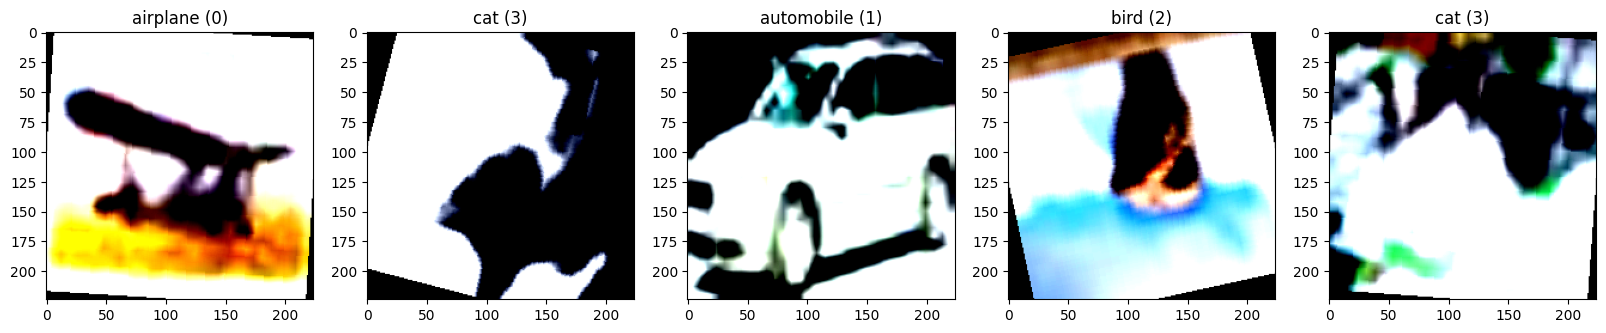

In [128]:
show_images(train_dataset_resnet18, 1, 5, True)

#### ResNet-18 (Feature Extraction)

In [26]:
resnet_18_fe = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet_18_fe.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [82]:
for p in resnet_18_fe.parameters():
    p.requires_grad = False
resnet_18_fe.fc = nn.Linear(in_features=512, out_features=10).to(device)

In [27]:
loaders = {
    'train': train_loader,
    'val': test_loader
}
optimizer = torch.optim.AdamW(resnet_18_fe.parameters(), lr=1e-4, weight_decay=1e-3)
criterion = nn.CrossEntropyLoss()
# train_model(resnet_18_fe, loaders, optimizer, criterion, 30, 'resnet_18_fe') # 30:25

#### ResNet-18 (Fine-Tuning)

In [84]:
for p in resnet_18_fe.parameters():
    p.requires_grad = True

In [ ]:
fc_params = []
other_params = []
for name, param in resnet_18_fe.named_parameters():
    if 'fc' in name:
        fc_params.append(param)
    else:
        other_params.append(param)
optimizer = torch.optim.AdamW(
    (
        {'params': other_params, 'lr': 1e-6},
        {'params': fc_params, 'lr': 1e-4}
    ),
    weight_decay=1e-3
)
# train_model(resnet_18_fe, loaders, optimizer, criterion, 40, 'resnet_18_ft', 30) # 1:16:52

#### Сравнение моделей

In [28]:
models_logs = [
    Path('./SimpleCNN'),
    Path('./resnet_18_fe'),
    Path('./resnet_18_ft')
]
metrics_logs = {}
for model_log in models_logs:
    metrics_logs[model_log.name] = {
        'epoch': [],
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }
    checkpoints = list(model_log.rglob('*.pt'))
    checkpoints_sorted = sorted(checkpoints, key=lambda x: int(x.stem.split('_')[1]))
    for checkpoint in checkpoints_sorted:
        c = torch.load(checkpoint, weights_only=True)
        metrics_logs[model_log.name]['epoch'].append(c['epoch'])
        metrics_logs[model_log.name]['train_loss'].append(c['train_loss'])
        metrics_logs[model_log.name]['train_acc'].append(c['train_acc'])
        metrics_logs[model_log.name]['val_loss'].append(c['val_loss'])
        metrics_logs[model_log.name]['val_acc'].append(c['val_acc'])

In [40]:
fig_loss = go.Figure()
for m_name in metrics_logs.keys():
    fig_loss.add_trace(go.Scatter(x=metrics_logs[m_name]['epoch'], y=metrics_logs[m_name]['train_loss'], mode='lines', name=f'train_loss ({m_name})'))
    fig_loss.add_trace(go.Scatter(x=metrics_logs[m_name]['epoch'], y=metrics_logs[m_name]['val_loss'], mode='lines', name=f'val_loss ({m_name})'))
fig_loss.update_layout(
    title='Функция потерь по эпохам',
    xaxis_title='Epoch',
    yaxis_title='Loss',
    legend_title='Метрики моделей'
)
fig_loss.show()

In [41]:
fig_acc = go.Figure()
for m_name in metrics_logs.keys():
    fig_acc.add_trace(go.Scatter(x=metrics_logs[m_name]['epoch'], y=metrics_logs[m_name]['train_acc'], mode='lines', name=f'train_acc ({m_name})'))
    fig_acc.add_trace(go.Scatter(x=metrics_logs[m_name]['epoch'], y=metrics_logs[m_name]['val_acc'], mode='lines', name=f'val_acc ({m_name})'))
fig_acc.update_layout(
    title='Accuracy по эпохам',
    xaxis_title='Epoch',
    yaxis_title='Accuracy',
    legend_title='Метрики моделей'
)
fig_acc.show()

In [42]:
simple_cnn = SimpleCNN()
simple_cnn.to(device)
checkpoint_simple_cnn = torch.load('./SimpleCNN/epoch_100.pt', map_location=device, weights_only=True)
simple_cnn.load_state_dict(checkpoint_simple_cnn['model_state_dict'])
preds_simple_cnn = predict(simple_cnn, test_loader)

Test mode:   0%|          | 0/157 [00:00<?, ?it/s]

In [43]:
resnet_18_fe = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet_18_fe.fc = nn.Linear(in_features=512, out_features=10)
resnet_18_fe.to(device)
checkpoint_resnet_18_fe = torch.load('./resnet_18_fe/epoch_30.pt', map_location=device, weights_only=True)
resnet_18_fe.load_state_dict(checkpoint_resnet_18_fe['model_state_dict'])
preds_resnet_18_fe = predict(resnet_18_fe, test_loader_resnet18)

Test mode:   0%|          | 0/157 [00:00<?, ?it/s]

In [44]:
resnet_18_ft = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet_18_ft.fc = nn.Linear(in_features=512, out_features=10)
resnet_18_ft.to(device)
checkpoint_resnet_18_ft = torch.load('./resnet_18_ft/epoch_70.pt', map_location=device, weights_only=True)
resnet_18_ft.load_state_dict(checkpoint_resnet_18_ft['model_state_dict'])
preds_resnet_18_ft = predict(resnet_18_ft, test_loader_resnet18)

Test mode:   0%|          | 0/157 [00:00<?, ?it/s]

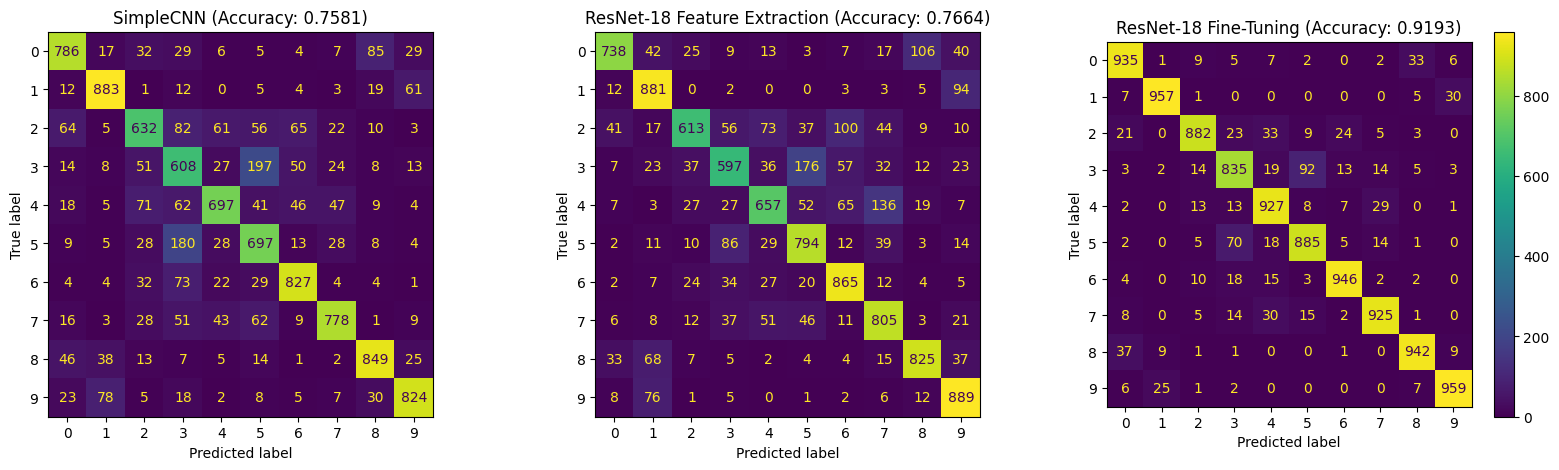

In [53]:
titles = ['SimpleCNN', 'ResNet-18 Feature Extraction', 'ResNet-18 Fine-Tuning']
y_true = [test_loader.dataset.targets, test_loader_resnet18.dataset.targets, test_loader_resnet18.dataset.targets]
y_pred = [preds_simple_cnn, preds_resnet_18_fe, preds_resnet_18_ft]
fix_cm, axes = plt.subplots(1, 3, figsize=(20, 5))
for i in range(len(titles)):
    cm = confusion_matrix(y_true[i], y_pred[i])
    disp = ConfusionMatrixDisplay(cm)
    colorbar = i == len(titles) - 1
    disp.plot(ax=axes[i], colorbar=colorbar)
    axes[i].set_title(titles[i] + f' (Accuracy: {accuracy_score(y_true[i], y_pred[i])})')
plt.show()